# 02 - Khám phá dữ liệu (EDA)

## Mục tiêu

- Tìm hiểu cấu trúc của dataset sau khi tích hợp.
- Thống kê số dòng và số cột.
- Kiểm tra kiểu dữ liệu.
- Thống kê các biến số.
- Khảo sát các biến phân loại.
- Kiểm tra dữ liệu thiếu và dữ liệu trùng.
- Phát hiện những giá trị có dấu hiệu bất thường.
- Trực quan hóa một số đặc điểm quan trọng của dữ liệu.

In [25]:
# Thêm thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# đọc file step1_merged.csv
df = pd.read_csv('../data/processed/step1_merged.csv')

In [27]:
# xem 5 dòng đầu tiên của dữ liệu
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,sao paulo,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,barreiras,BA,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,vianopolis,GO,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,sao goncalo do amarante,RN,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,santo andre,SP,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [28]:
# xem kích thước file dữ liệu
print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])

Số dòng: 112650
Số cột: 26


In [29]:
# xem tên các cột trong dữ liệu
print(df.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [30]:
#kiểm tra kiểu dữ liệu của các cột 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  str    
 1   customer_id                    112650 non-null  str    
 2   order_status                   112650 non-null  str    
 3   order_purchase_timestamp       112650 non-null  str    
 4   order_approved_at              112635 non-null  str    
 5   order_delivered_carrier_date   111456 non-null  str    
 6   order_delivered_customer_date  110196 non-null  str    
 7   order_estimated_delivery_date  112650 non-null  str    
 8   order_item_id                  112650 non-null  int64  
 9   product_id                     112650 non-null  str    
 10  seller_id                      112650 non-null  str    
 11  shipping_limit_date            112650 non-null  str    
 12  price                          112650 non

In [31]:
# thống kê mô tả của dữ liệu
df.describe()

,order_item_id,price,freight_value,customer_zip_code_prefix,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,112650.000000,112650.000000,112650.000000,112650.000000,111047.000000,111047.000000,111047.000000,112632.000000,112632.000000,112632.000000,112632.000000
mean,1.197834,120.653739,19.990320,35119.309090,48.775978,787.867029,2.209713,2093.672047,30.153669,16.593766,22.996546
std,0.705124,183.633928,15.806405,29866.120801,10.025581,652.135608,1.721438,3751.596884,16.153449,13.443483,11.707268
min,1.000000,0.850000,0.000000,1003.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,1.000000,39.900000,13.080000,11310.000000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,1.000000,74.990000,16.260000,24340.000000,52.000000,603.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,1.000000,134.900000,21.150000,59028.750000,57.000000,987.000000,3.000000,1800.000000,38.000000,20.000000,30.000000
max,21.000000,6735.000000,409.680000,99990.000000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [32]:
# Kiểm tra số lượng và tần suất của các biến phân loại
print(df['customer_state'].value_counts())
print(df['order_status'].value_counts())
print(df['product_category_name'].value_counts().head(20))

customer_state
SP    47449
RJ    14579
MG    13129
RS     6235
PR     5740
SC     4176
BA     3799
DF     2406
GO     2333
ES     2256
PE     1806
CE     1478
PA     1080
MT     1055
MA      824
MS      819
PB      602
PI      542
RN      529
AL      444
SE      385
TO      315
RO      278
AM      165
AC       92
AP       82
RR       52
Name: count, dtype: int64
order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64
product_category_name
cama_mesa_banho                11115
beleza_saude                    9670
esporte_lazer                   8641
moveis_decoracao                8334
informatica_acessorios          7827
utilidades_domesticas           6964
relogios_presentes              5991
telefonia                       4545
ferramentas_jardim              4347
automotivo                      4235
brinquedos                      4117
cool_stuff   

In [33]:
# kiểm tra dữ liệu thiếu
missing = df.isna().sum()
print(missing[missing > 0])
# tính tỷ lệ phần trăm dữ liệu thiếu
print("\nTỷ lệ phần trăm dữ liệu thiếu:")
missing_percent = (df.isna().mean() * 100)
print(
    missing_percent[missing_percent > 0]
    .sort_values(ascending=False)
)

order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
product_category_name            1603
product_name_lenght              1603
product_description_lenght       1603
product_photos_qty               1603
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
dtype: int64

Tỷ lệ phần trăm dữ liệu thiếu:
order_delivered_customer_date    2.178429
product_name_lenght              1.422992
product_category_name            1.422992
product_description_lenght       1.422992
product_photos_qty               1.422992
order_delivered_carrier_date     1.059920
product_weight_g                 0.015979
product_height_cm                0.015979
product_length_cm                0.015979
product_width_cm                 0.015979
order_approved_at                0.013316
dtype: float64


In [34]:
# kiểm tra dữ liệu trùng lặp
duplicate_count = df.duplicated().sum()
print(f"Số lượng dữ liệu trùng lặp: {duplicate_count}")

Số lượng dữ liệu trùng lặp: 0


In [35]:
# tìm giá trị bất thường
print("Giá nhỏ nhất:", df['price'].min())
print("Giá lớn nhất:", df['price'].max())
print("Price < 0:", (df['price'] < 0).sum())
print("Freight < 0:", (df['freight_value'] < 0).sum())

Giá nhỏ nhất: 0.85
Giá lớn nhất: 6735.0
Price < 0: 0
Freight < 0: 0


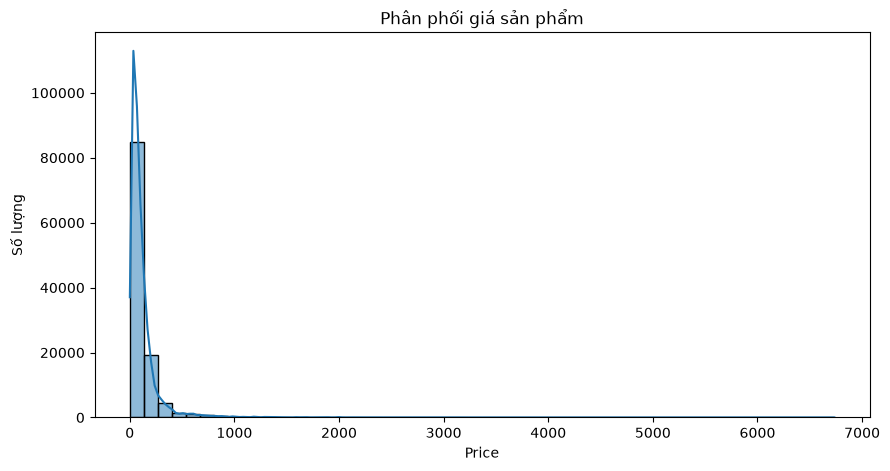

In [36]:
# Vẽ Histogram giá sản phẩm
plt.figure(figsize=(10, 5))

sns.histplot(
    df['price'],
    bins=50,
    kde=True
)

plt.title('Phân phối giá sản phẩm')
plt.xlabel('Price')
plt.ylabel('Số lượng')

plt.show()

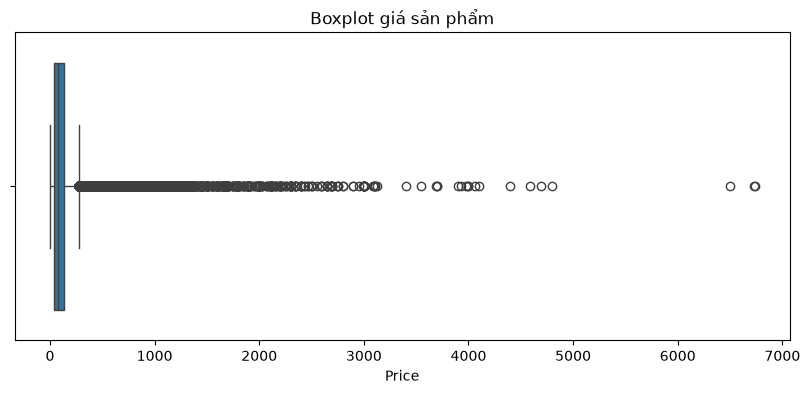

In [37]:
# Boxplot giá sản phẩm
plt.figure(figsize=(10, 4))

sns.boxplot(x=df['price'])

plt.title('Boxplot giá sản phẩm')
plt.xlabel('Price')

plt.show()

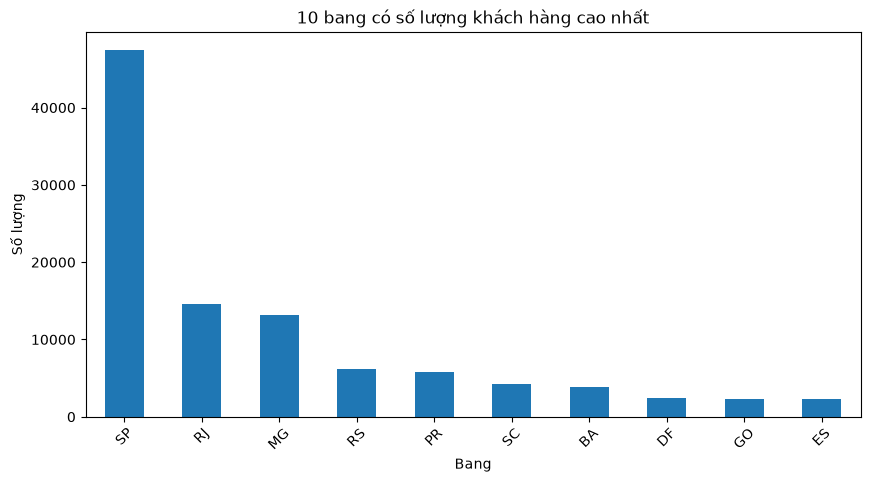

In [38]:
# Vẽ biểu đồ phân loại
top_states = df['customer_state'].value_counts().head(10)

plt.figure(figsize=(10, 5))

top_states.plot(kind='bar')

plt.title('10 bang có số lượng khách hàng cao nhất')
plt.xlabel('Bang')
plt.ylabel('Số lượng')

plt.xticks(rotation=45)

plt.show()

In [39]:
#Kiểm tra thời gian
df['order_purchase_timestamp'].head()

0    2017-10-02 10:56:33
1    2018-07-24 20:41:37
2    2018-08-08 08:38:49
3    2017-11-18 19:28:06
4    2018-02-13 21:18:39
Name: order_purchase_timestamp, dtype: str

# Kết luận

Sau quá trình khám phá dữ liệu:

- Dataset có ... dòng và ... cột.
- Dataset gồm các biến số, biến phân loại và biến thời gian.
- Có ... cột có dữ liệu thiếu.
- Có ... dòng có dấu hiệu trùng lặp.
- Cột `price` có sự phân bố ... và có dấu hiệu xuất hiện giá trị ngoại lai.
- Một số cột cần được chuẩn hóa kiểu dữ liệu.
- Các vấn đề về dữ liệu thiếu, dữ liệu trùng và ngoại lai sẽ được xử lý ở các bước tiếp theo.